# Parte 0 — Testes sintéticos

Validamos o rastreamento em um ambiente controlado antes do MOT17: vídeos 128×128, 48 quadros, 5–15 elipses, oclusão real, detector simulado e métricas próprias. O notebook reúne os resultados para a apresentação; geração, associação, avaliação e experimentos permanecem nos arquivos `.py`.

**Objetivo:** verificar que o baseline funciona no piso fácil e mostrar onde perde identidades ao aumentar a dificuldade. Não há treino nesta parte.

Execute todas as células a partir da raiz do repositório, com o ambiente de `requirements-detector.txt` selecionado no kernel.

In [1]:
from pathlib import Path
import io
import unittest
import numpy as np
from IPython.display import display, Image, HTML, Markdown
from synthetic import generate, corrupt_detections
from run_synthetic import run, run_experiments
from metrics import evaluate

OUTPUT = Path("outputs/parte0")
SEED = 0

def show_table(rows, columns):
    text = "| " + " | ".join(columns) + " |\n"
    text += "| " + " | ".join(["---"] * len(columns)) + " |\n"
    text += "\n".join("| " + " | ".join(str(value) for value in row) + " |" for row in rows)
    display(Markdown(text))

## 1. Gerador e contrato

`synthetic.py`, função `generate`: controla número de objetos, velocidade em pixels/quadro, duração da oclusão, ruído, contraste e seed. As elipses têm tamanhos variados e são desenhadas em ordem de profundidade. A visibilidade é a fração de pixels que ainda pertence ao objeto após desenhar os objetos à frente.

`scene.gt` possui `frame,id,x,y,w,h,visibility`; posições são 0-based, quadros e IDs começam em 1. Inclui objetos totalmente ocultos para inspecionar a oclusão. Na avaliação sintética, usamos apenas observações com algum pixel visível — regra distinta do protocolo MOT.

In [2]:
scene = generate(n_objects=5, speed=0.3, occlusion=10, seed=SEED)
print("Vídeo:", scene.frames.shape, "— quadros, altura, largura, canais")
print("GT:", scene.gt.shape, "— frame,id,x,y,w,h,visibility")
assert scene.frames.shape == (48, 128, 128, 3)
show_table([[int(r[0]), int(r[1]), *[round(float(v), 2) for v in r[2:]]]
            for r in scene.gt[:5]], ["Quadro", "ID", "x", "y", "w", "h", "Visibilidade"])

Vídeo: (48, 128, 128, 3) — quadros, altura, largura, canais
GT: (240, 7) — frame,id,x,y,w,h,visibility


| Quadro | ID | x | y | w | h | Visibilidade |
| --- | --- | --- | --- | --- | --- | --- |
| 1 | 1 | 60.0 | 92.0 | 8.0 | 8.0 | 1.0 |
| 1 | 2 | 27.0 | 87.0 | 18.0 | 18.0 | 1.0 |
| 1 | 3 | 57.56 | 13.26 | 12.88 | 13.48 | 1.0 |
| 1 | 4 | 82.18 | 13.81 | 11.64 | 12.38 | 1.0 |
| 1 | 5 | 106.37 | 13.19 | 11.26 | 13.61 | 1.0 |

## 2. Oclusão real: desaparecimento e retorno

O objeto 1 fica em (64, 96) e o objeto 2, maior e à frente, atravessa sua posição. Ele cobre os pixels do objeto 1 por exatamente dez quadros; a ausência não é produzida apagando detecções manualmente.

`run_synthetic.py`, função `run_experiments`, produz a tira antes/durante/depois, a animação e os experimentos abaixo. Todas as saídas também podem ser regeneradas com `python run_synthetic.py`.

{
  "idf1": 1.0,
  "idtp": 240,
  "idfp": 0,
  "idfn": 0,
  "id_switches": 0,
  "fragmentations": 0,
  "gt_identities": 5,
  "predicted_identities": 5,
  "unique_count_error": 0
}
Artefatos: outputs/parte0
Objeto 1 totalmente oculto nos quadros 20–29: 10 quadros.


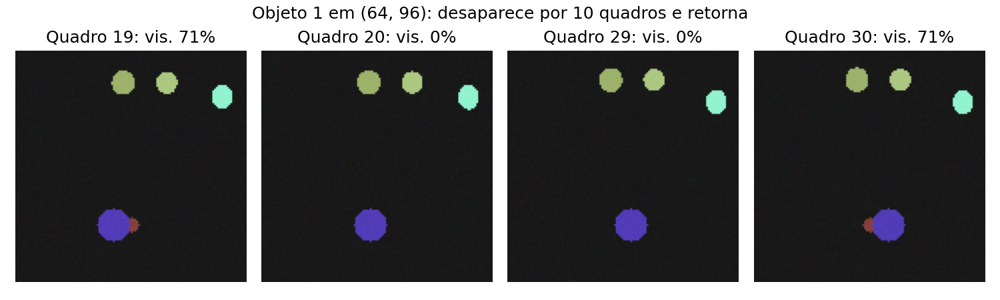

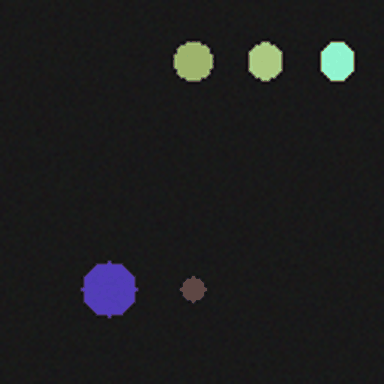

In [3]:
results = run_experiments(OUTPUT)
hidden = results["fully_hidden_frames"]
assert len(hidden) == 10 and np.all(np.diff(hidden) == 1)
print(f"Objeto 1 totalmente oculto nos quadros {hidden[0]}–{hidden[-1]}: {len(hidden)} quadros.")
display(Image(filename=str(OUTPUT / "oclusao.png")))
display(Image(data=(OUTPUT / "oclusao.gif").read_bytes(), format="gif"))

## 3. Detector simulado

`synthetic.py`, função `corrupt_detections`: recebe GT sintético, elimina objetos totalmente ocultos, descarta uma fração das caixas visíveis, adiciona ruído em pixels às coordenadas e injeta FP com quantidade Poisson por quadro. A saída `frame,x,y,w,h,score` não possui identidades.

Aqui o GT serve para simular um detector controlado. O baseline recebe somente as caixas e nunca as identidades ou a visibilidade. A Parte 5 usa as detecções reais como entrada do gerador de estresse.

In [4]:
clean = corrupt_detections(scene.gt, seed=SEED)
noisy = corrupt_detections(scene.gt, drop=0.3, jitter=2.0, false_positives=1.0, seed=SEED)
assert clean.shape[1] == noisy.shape[1] == 6
print("Caixas limpas:", len(clean), "| Caixas degradadas:", len(noisy))
show_table([[int(r[0]), *[round(float(v), 2) for v in r[1:]]] for r in noisy[:5]],
           ["Quadro", "x", "y", "w", "h", "Score"])
print("A quantidade final mistura descartes e FP; não representa recall.")

Caixas limpas: 230 | Caixas degradadas: 203


| Quadro | x | y | w | h | Score |
| --- | --- | --- | --- | --- | --- |
| 1 | 59.74 | 93.28 | 8.21 | 6.93 | 0.9 |
| 1 | 29.61 | 88.89 | 16.59 | 15.47 | 0.9 |
| 1 | 57.64 | 8.61 | 12.44 | 10.98 | 0.9 |
| 1 | 105.74 | 14.02 | 13.35 | 13.35 | 0.9 |
| 2 | 60.7 | 93.81 | 8.19 | 6.51 | 0.9 |

A quantidade final mistura descartes e FP; não representa recall.


## 4. Testes construídos à mão das métricas

`metrics.py`, função `evaluate`: calcula IDF1 com associação global de identidades, switches e fragmentações. Os casos abaixo têm caixas perfeitas, portanto isolam erros de identidade.

A troca de dois IDs a partir do quadro 3 deve produzir **IDF1=0,5 e dois switches**. Partir apenas uma identidade em dois IDs deve produzir **IDF1=0,75 e um switch**. A divisão sem quadro perdido não é uma fragmentação de observação: fragmentação exige interrupção e retomada. O quarto caso demonstra essa distinção.

In [5]:
gt = np.array([[f, i, 30*i, 0, 10, 10] for f in range(1, 5) for i in (1, 2)], float)
swapped = gt.copy()
swapped[swapped[:, 0] >= 3, 1] = 3 - swapped[swapped[:, 0] >= 3, 1]
split = gt.copy()
split[(split[:, 0] >= 3) & (split[:, 1] == 1), 1] = 3
gap = gt[~((gt[:, 0] == 2) & (gt[:, 1] == 1))]
cases = [("Perfeito", gt, (1, 0, 0)), ("Troca de dois IDs", swapped, (0.5, 2, 0)),
         ("Uma identidade dividida", split, (0.75, 1, 0)),
         ("Quadro perdido e retomada", gap, (14/15, 0, 1))]
rows = []
for label, predicted, expected in cases:
    value = evaluate(gt, predicted)
    actual = (value["idf1"], value["id_switches"], value["fragmentations"])
    assert np.allclose(actual, expected), (label, actual, expected)
    rows.append([label, f"{actual[0]:.4f}", actual[1], actual[2], "Passou"])
show_table(rows, ["Caso", "IDF1", "Switches", "Fragmentações", "Teste"])

| Caso | IDF1 | Switches | Fragmentações | Teste |
| --- | --- | --- | --- | --- |
| Perfeito | 1.0000 | 0 | 0 | Passou |
| Troca de dois IDs | 0.5000 | 2 | 0 | Passou |
| Uma identidade dividida | 0.7500 | 1 | 0 | Passou |
| Quadro perdido e retomada | 0.9333 | 0 | 1 | Passou |

## 5. Baseline no piso fácil

`baseline.py`, classe `IoUTracker`: associa a última caixa observada com Hungarian e IoU, inicia IDs imediatamente e tolera dois quadros intermediários sem observação. Não prevê movimento.

`run_synthetic.py`, função `run`, processa todos os quadros, inclusive vazios. No piso fácil: cinco objetos lentos, sem oclusão programada e detector sem corrupção.

In [6]:
easy = results["easy"]
assert easy["idf1"] >= 0.98
assert easy["id_switches"] == 0
show_table([[f'{easy["idf1"]:.4f}', easy["id_switches"], easy["fragmentations"],
             easy["predicted_identities"], easy["gt_identities"]]],
           ["IDF1", "Switches", "Fragmentações", "IDs previstos", "IDs reais"])

| IDF1 | Switches | Fragmentações | IDs previstos | IDs reais |
| --- | --- | --- | --- | --- |
| 1.0000 | 0 | 0 | 5 | 5 |

## 6. Onde o baseline começa a quebrar

Variamos um parâmetro por vez, usando seeds 0, 1 e 2. Os demais ficam no padrão: cinco objetos, velocidade 0,3 e sem oclusão programada. O detector não recebe corrupção nesses três eixos, isolando a dificuldade geométrica/temporal.

As barras mostram desvio padrão amostral entre três seeds, não intervalo de confiança. Mais objetos podem ocasionar sobreposição natural mesmo com duração programada igual a zero.

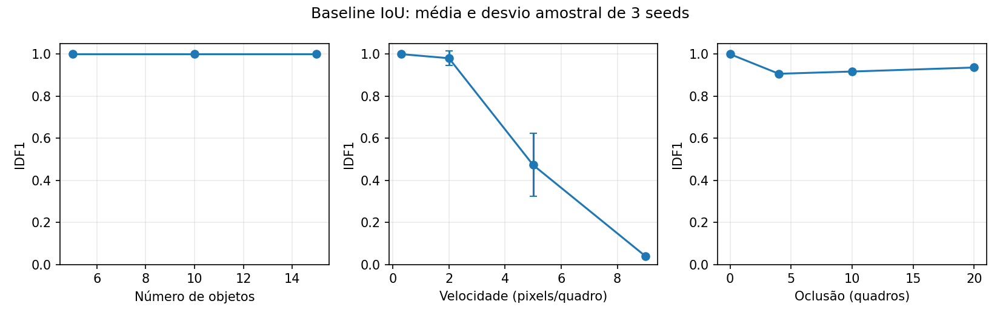

| Parâmetro | Valor | IDF1 médio | Desvio | Switches médios | IDs médios |
| --- | --- | --- | --- | --- | --- |
| n_objects | 5 | 1.0000 | 0.0000 | 0.00 | 5.00 |
| n_objects | 10 | 1.0000 | 0.0000 | 0.00 | 10.00 |
| n_objects | 15 | 1.0000 | 0.0000 | 0.00 | 15.00 |
| speed | 0.3 | 1.0000 | 0.0000 | 0.00 | 5.00 |
| speed | 2 | 0.9806 | 0.0337 | 0.67 | 5.00 |
| speed | 5 | 0.4731 | 0.1497 | 94.33 | 92.00 |
| speed | 9 | 0.0403 | 0.0025 | 227.33 | 208.00 |
| occlusion | 0 | 1.0000 | 0.0000 | 0.00 | 5.00 |
| occlusion | 4 | 0.9068 | 0.0000 | 1.00 | 6.00 |
| occlusion | 10 | 0.9174 | 0.0000 | 1.00 | 6.00 |
| occlusion | 20 | 0.9364 | 0.0000 | 1.00 | 6.00 |

In [7]:
display(Image(filename=str(OUTPUT / "baseline_dificuldade.png")))
rows = []
for parameter, experiment in results["experiments"].items():
    for value, group in zip(experiment["values"], experiment["metrics"]):
        scores = np.array([m["idf1"] for m in group])
        rows.append([parameter, value, f"{scores.mean():.4f}", f"{scores.std(ddof=1):.4f}",
                     f'{np.mean([m["id_switches"] for m in group]):.2f}',
                     f'{np.mean([m["predicted_identities"] for m in group]):.2f}'])
show_table(rows, ["Parâmetro", "Valor", "IDF1 médio", "Desvio", "Switches médios", "IDs médios"])

### Leitura do gráfico

- **Quantidade:** de 5 a 15 objetos, IDF1 permanece 1 neste cenário lento. Aumentar a quantidade isoladamente não foi suficiente para quebrar o baseline.
- **Velocidade:** IDF1 médio cai de 1 para 0,4731 a 5 pixels/quadro e 0,0403 a 9 pixels/quadro. O deslocamento reduz a sobreposição com a última caixa, gerando novas identidades.
- **Oclusão:** lacunas de 4, 10 e 20 quadros ultrapassam a tolerância de dois quadros do baseline. Em todos os casos aparece um switch e um ID extra: 6 IDs previstos para 5 objetos. O IDF1 sobe ligeiramente entre 4 e 20 porque a avaliação exclui quadros totalmente ocultos; a ponderação das observações muda. A identidade continua sendo perdida, portanto essa subida não indica melhora na recuperação.

No exemplo de detector degradado abaixo, IDF1 cai de 0,9174 para 0,2725 e a contagem sobe de 6 para 71 IDs. Descartes, deslocamentos e FP foram aplicados juntos; não atribuímos toda a queda a um único fator.

## 7. Efeito de um detector degradado

Comparamos a mesma cena com oclusão de dez quadros, mantendo o baseline fixo. O segundo cenário descarta 30% das caixas, usa jitter de 2 pixels e injeta em média um FP por quadro. Esse exemplo é demonstrativo, com uma seed; o estudo com três intensidades e três seeds está na Parte 5.

In [8]:
rows = []
for label, parameters in [("Sem corrupção", {}),
                           ("Detector degradado", dict(drop=0.3, jitter=2, false_positives=1))]:
    value = run(scene, SEED, **parameters)
    rows.append([label, f'{value["idf1"]:.4f}', value["id_switches"],
                 value["fragmentations"], value["predicted_identities"], value["gt_identities"]])
show_table(rows, ["Detector", "IDF1", "Switches", "Fragmentações", "IDs previstos", "IDs reais"])

| Detector | IDF1 | Switches | Fragmentações | IDs previstos | IDs reais |
| --- | --- | --- | --- | --- | --- |
| Sem corrupção | 0.9174 | 1 | 0 | 6 | 5 |
| Detector degradado | 0.2725 | 21 | 48 | 71 | 5 |

## 8. Verificação automatizada

Executamos os testes da Parte 0 em `tests/test_core.py` e `tests/test_synthetic.py`, incluindo oclusão, repetibilidade, NMS, associação e métricas. Falhas interrompem a execução do notebook.

In [9]:
suite = unittest.TestSuite()
loader = unittest.TestLoader()
for module in ["tests.test_core", "tests.test_synthetic"]:
    suite.addTests(loader.loadTestsFromName(module))
log = io.StringIO()
check = unittest.TextTestRunner(stream=log, verbosity=1).run(suite)
print(log.getvalue())
assert check.wasSuccessful(), "Falha nos testes da Parte 0"

.............
----------------------------------------------------------------------
Ran 13 tests in 0.336s

OK



## 9. Conclusão e ligação com o MOT17

O piso fácil valida o funcionamento básico; os casos manuais verificam que IDF1 distingue troca de IDs de divisão de uma identidade. A visibilidade medida nos pixels comprova a oclusão real. O gráfico mostra os limites da associação pela última caixa diante de deslocamento e lacunas.

As curvas não precisam cair monotonamente: apenas três seeds são usadas, e a duração programada controla uma oclusão específica, não todas as sobreposições. A cena sintética não representa toda a dificuldade de uma câmera real.

A Parte 1 reutiliza associação e métricas no MOT17; a Parte 5 testa as detecções congeladas. `outputs/parte0/results.json` guarda os resultados completos. As imagens aparecem nas saídas salvas deste notebook, sem necessidade de publicar dados, conversas ou caminhos pessoais.